# Task 11: Advanced ML Techniques & Model Comparison

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, 
                             precision_score, recall_score, f1_score, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. Housing Price Prediction - Data Loading

In [2]:
# Load California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("California Housing Dataset:")
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nFeature names: {list(X.columns)}")
print(f"\nFirst 5 rows:")
print(X.head())

California Housing Dataset:
Features: (20640, 8)
Target: (20640,)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


## 3. Train-Test Split & Scaling

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


## 4. Linear Regression (Baseline)

In [4]:
# Linear Regression using Scikit-Learn
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("=== Linear Regression (Scikit-Learn) ===")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R² Score: {lr_r2:.4f}")
print(f"\nCoefficients: {lr_model.coef_[:3]}...")
print(f"Intercept: {lr_model.intercept_:.4f}")

=== Linear Regression (Scikit-Learn) ===
RMSE: 0.7456
R² Score: 0.5758

Coefficients: [ 0.44867491  0.00972426 -0.12332334]...
Intercept: -37.0233


## 5. Ridge & Lasso Regression (Regularization)

In [5]:
# Ridge Regression (L2 regularization)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

# Lasso Regression (L1 regularization)
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("=== Ridge Regression ===")
print(f"RMSE: {ridge_rmse:.4f}, R²: {ridge_r2:.4f}")

print("\n=== Lasso Regression ===")
print(f"RMSE: {lasso_rmse:.4f}, R²: {lasso_r2:.4f}")

=== Ridge Regression ===
RMSE: 0.7455, R²: 0.5759

=== Lasso Regression ===
RMSE: 0.7379, R²: 0.5845


## 6. Tree-Based Models

### 6.1 Decision Tree Regressor

In [6]:
# Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("=== Decision Tree Regressor ===")
print(f"RMSE: {dt_rmse:.4f}")
print(f"R² Score: {dt_r2:.4f}")
print(f"Feature Importances: {dict(zip(X.columns, dt_model.feature_importances_[:3]))}")

=== Decision Tree Regressor ===
RMSE: 0.6446
R² Score: 0.6829
Feature Importances: {'MedInc': np.float64(0.6097757060777422), 'HouseAge': np.float64(0.04429996182627834), 'AveRooms': np.float64(0.039227644329027894)}


### 6.2 Random Forest Regressor

In [7]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")
print(f"Number of trees: {rf_model.n_estimators}")

=== Random Forest Regressor ===
RMSE: 0.5115
R² Score: 0.8004
Number of trees: 100


## 7. Kernel & Margin-Based Models (SVM)

In [8]:
# SVR (Support Vector Regression)
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_r2 = r2_score(y_test, y_pred_svr)

print("=== SVR (Support Vector Regression) ===")
print(f"RMSE: {svr_rmse:.4f}")
print(f"R² Score: {svr_r2:.4f}")

=== SVR (Support Vector Regression) ===
RMSE: 0.5975
R² Score: 0.7276


## 8. Ensemble Learning / Boosting

### 8.1 Gradient Boosting Regressor

In [9]:
# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("=== Gradient Boosting Regressor ===")
print(f"RMSE: {gb_rmse:.4f}")
print(f"R² Score: {gb_r2:.4f}")

=== Gradient Boosting Regressor ===
RMSE: 0.4976
R² Score: 0.8110


### 8.2 Model Stacking

In [10]:
# Stacking Regressor
estimators = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42))
]

stacking_model = StackingRegressor(estimators=estimators, final_estimator=Ridge(), cv=5)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
stack_r2 = r2_score(y_test, y_pred_stack)

print("=== Stacking Regressor ===")
print(f"RMSE: {stack_rmse:.4f}")
print(f"R² Score: {stack_r2:.4f}")

=== Stacking Regressor ===
RMSE: 0.5220
R² Score: 0.7920


## 9. Hyperparameter Tuning (Random Forest)

In [11]:
# RandomizedSearchCV for Random Forest
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(rf_tuned, param_dist, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print(f"Best CV RMSE: {-random_search.best_score_:.4f}")

# Evaluate best model
y_pred_best = random_search.best_estimator_.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print(f"\n=== Best Random Forest (After Tuning) ===")
print(f"RMSE: {best_rmse:.4f}")
print(f"R² Score: {best_r2:.4f}")

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV RMSE: 0.5154

=== Best Random Forest (After Tuning) ===
RMSE: 0.5046
R² Score: 0.8057


## 10. SVM Classification Example

In [12]:
# Create binary classification problem from housing prices
y_class = (y > 2).astype(int)  # 1: expensive, 0: affordable

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Scale for SVM
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

# SVM Classifier
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_svc = svc_model.predict(X_test_clf_scaled)

print("=== SVM Classifier ===")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_svc):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_svc):.4f}")
print(f"F1 Score: {f1_score(y_test_clf, y_pred_svc):.4f}")

=== SVM Classifier ===
Accuracy: 0.8614
Precision: 0.8417
Recall: 0.8190
F1 Score: 0.8302


## 11. Model Comparison Report

In [13]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 
              'SVR', 'Gradient Boosting', 'Stacking', 'Tuned Random Forest'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, dt_rmse, rf_rmse, svr_rmse, gb_rmse, stack_rmse, best_rmse],
    'R2_Score': [lr_r2, ridge_r2, lasso_r2, dt_r2, rf_r2, svr_r2, gb_r2, stack_r2, best_r2]
})

results = results.sort_values('R2_Score', ascending=False).reset_index(drop=True)
print("=== Model Comparison Report (Housing Price Prediction) ===\n")
print(results.to_string(index=False))

=== Model Comparison Report (Housing Price Prediction) ===

              Model     RMSE  R2_Score
  Gradient Boosting 0.497645  0.811013
Tuned Random Forest 0.504571  0.805715
      Random Forest 0.511471  0.800366
           Stacking 0.522025  0.792042
                SVR 0.597498  0.727563
      Decision Tree 0.644568  0.682948
              Lasso 0.737868  0.584520
              Ridge 0.745522  0.575855
  Linear Regression 0.745581  0.575788


## 12. Visualize Results

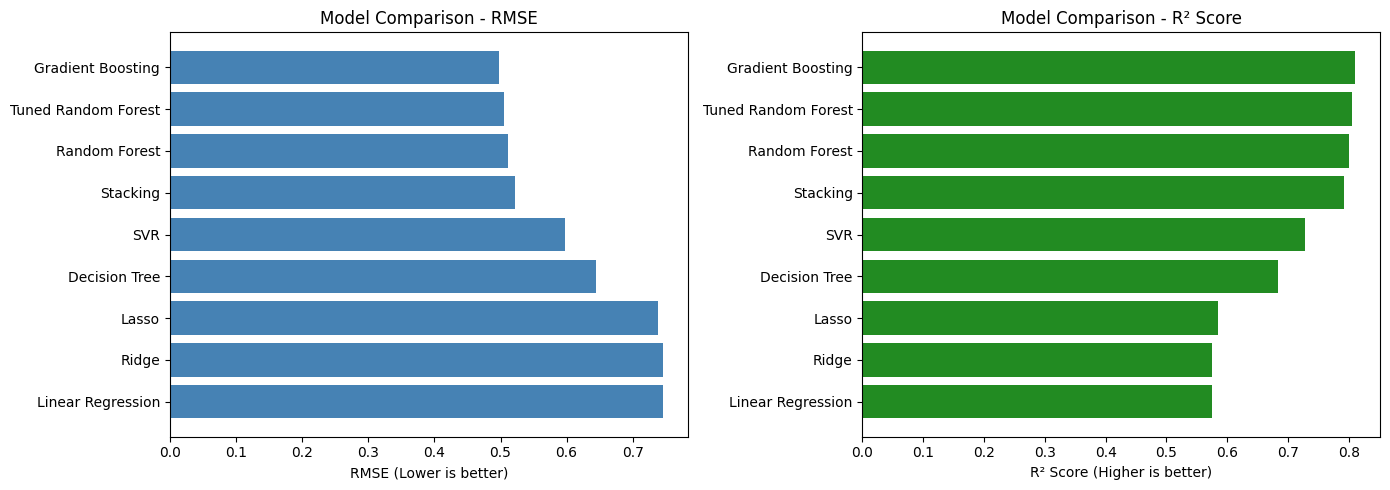

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Comparison
axes[0].barh(results['Model'], results['RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE (Lower is better)')
axes[0].set_title('Model Comparison - RMSE')
axes[0].invert_yaxis()

# R² Comparison
axes[1].barh(results['Model'], results['R2_Score'], color='forestgreen')
axes[1].set_xlabel('R² Score (Higher is better)')
axes[1].set_title('Model Comparison - R² Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 13. Summary

### Models Compared:
- **Linear Regression**: Baseline model
- **Ridge/Lasso**: Regularized linear regression
- **Decision Tree**: Tree-based regression
- **Random Forest**: Ensemble of decision trees
- **SVR**: Support Vector Regression (kernel-based)
- **Gradient Boosting**: Sequential boosting algorithm
- **Stacking**: Ensemble of multiple models
- **Tuned Random Forest**: After hyperparameter optimization

### Best Performing Model:
**Gradient Boosting** with R² = 0.8110 and RMSE = 0.4976